# $\text{ARIMA}(p,d,q)$

ARIMA stands for Auto Regressive Integrated Moving Average. The intent of $\text{ARIMA}(p,d,q)$ is to construct a stationary, $\text{ARMA}(p,q)$ time series from a non-stationary time series by differencing $d$ times. Recall that an $\text{ARMA}(p,q)$ process is defined by,

$
\begin{align}
X_t = \varepsilon_t + \sum_{i=1}^p \varphi_i X_{t-i} + \sum_{i=1}^q \vartheta_i \varepsilon_{t-i}
\end{align}
\tag{1}
$

In terms of the lag operator $L X_t = X_{t-1}, L^2 X_t = X_{t-2}, L^3 X_t = X_{t-3}, \ldots$, The $\text{ARMA}(p,q)$ model can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{2}
$

The difference operator is given by $\Delta = (1 - L)$. If $X_t$ is stationary after $d$ differences it follows that $\left( 1 - L \right)^d X_t$ is stationary. This is the definition of integration order. Thus, $\text{ARIMA}(p,d,q)$ can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) \left( 1 - L \right)^d X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{3}
$

The procedure followed to determine the order and coefficients of an $\text{ARIMA}(p,d,q)$ series is as follows.

1. Use ADF test to determine if series is stationary. To determine $d$ difference series until ADF test fails.
2. User PACF/ACF analysis to determine $p$ and $q$.
3. Perform regression on differenced series to determine coefficients.

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats, adf
from lib.plots import stack, comparison

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def pacf_acf_plot(t, samples, nlags, σ, φ):
    title = f"AR(1) ACF-PACF σ={σ}, $\\varphi=${φ}"
    tacf, acf = stats.compute_acf(t, samples, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(samples, nlags=nlags)
    comparison([acf, pacf], [tacf, tpacf], labels=["ACF", "PACF"], ylim=(-0.1, 1.0), title=title, figsize=(10, 6))

## $\text{ARIMA}(1,1,0)$ Example

In [3]:
nsample = 1000
σ = 1.0
nlags = 10

In [4]:
φ = [0.5]
d = 1
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)

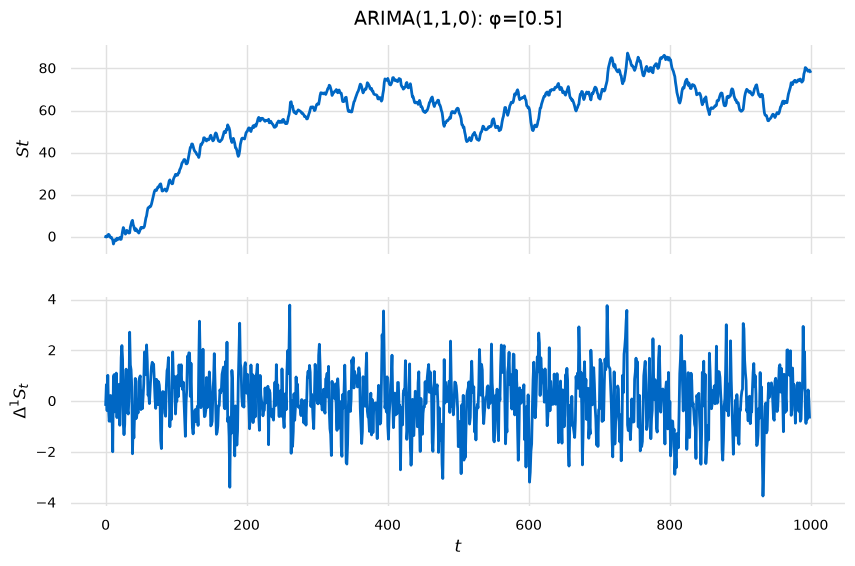

In [5]:
title=f"ARIMA(1,1,0): φ={φ}"
stack([arima_data, diff_1], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

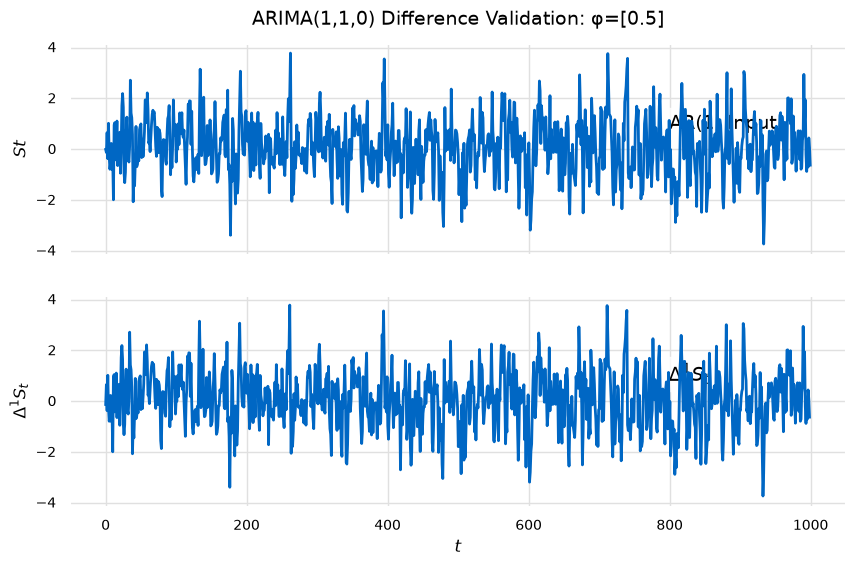

In [6]:
title = f"ARIMA(1,1,0) Difference Validation: φ={φ}"
stack([ar, diff_1], title=title, labels=[r"AR(1) Input", r"$\Delta^1 S_t$"], xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

In [7]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   0.431547 │
├────────────────┼────────────┤
│ pvalue         │   0.808686 │
├────────────────┼────────────┤
│ Lags           │   3        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [8]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "82c07634-1a22-463e-a812-da27f1d4937c",
                "label": "$t$",
                "value": 0.43154683787180537
            },
            "pval": {
                "test_id": "82c07634-1a22-463e-a812-da27f1d4937c",
                "label": "$p-value$",
                "value": 0.8086862576139743
            },
            "params": [],
            "sig": {
                "test_id": "82c07634-1a22-463e-a812-da27f1d4937c",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "82c07634-1a22-463e-a812-da27f1d4937c",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "82c07634-1a22-463e-a812-da27f1d4937c"
        },
      

In [9]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -15.5664      │
├────────────────┼───────────────┤
│ pvalue         │   2.67329e-27 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [10]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$t$",
                "value": -15.56638296864543
            },
            "pval": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$p-value$",
                "value": 2.6732896843617064e-27
            },
            "params": [],
            "sig": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b"
        },
   

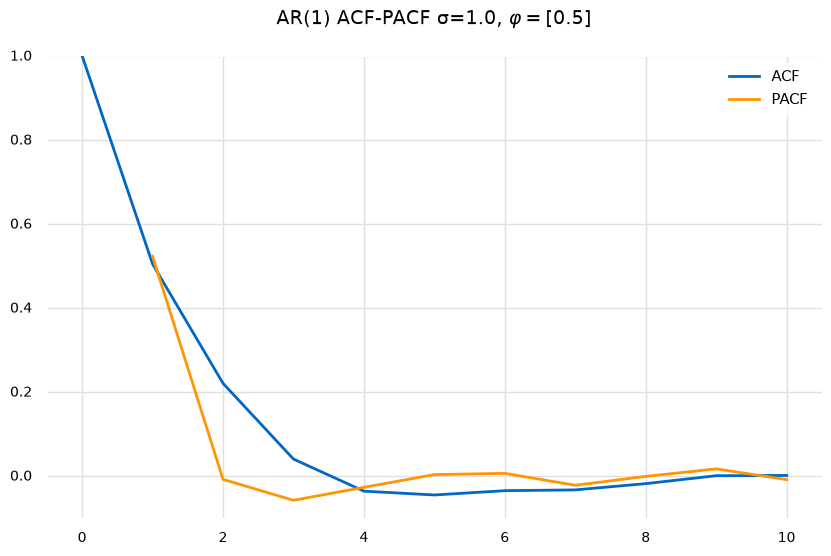

In [11]:
pacf_acf_plot(t, diff_1, nlags, σ, φ)

In [12]:
result, result_model = arima.compute_ar_estimate(diff_1, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1395.294
Date:                Sun, 30 Aug 2026   AIC                           2796.587
Time:                        11:23:24   BIC                           2811.308
Sample:                             0   HQIC                          2802.182
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0777      0.062      1.244      0.214      -0.045       0.200
ar.L1          0.5041      0.026     19.161      0.000       0.453       0.556
sigma2         0.9562      0.041     23.227      0.000       0.876       1.037
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):                 1.50
Prob(Q):                              0.45   Prob(JB):                         0.47
Heteroskedasticity (H):               1.36   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$t$",
                "value": -15.56638296864543
            },
            "pval": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$p-value$",
                "value": 2.6732896843617064e-27
            },
            "params": [],
            "sig": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "c51e5dba-6083-4fea-ba5d-f8e3bc41002b"
        },
   

## $\text{ARIMA}(1,2,0)$ Example

In [14]:
φ = [0.75]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

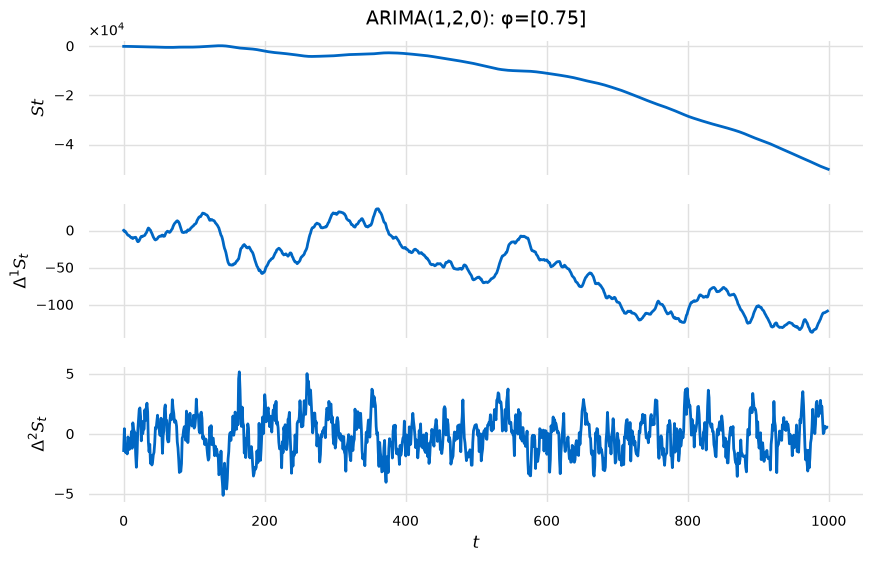

In [15]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

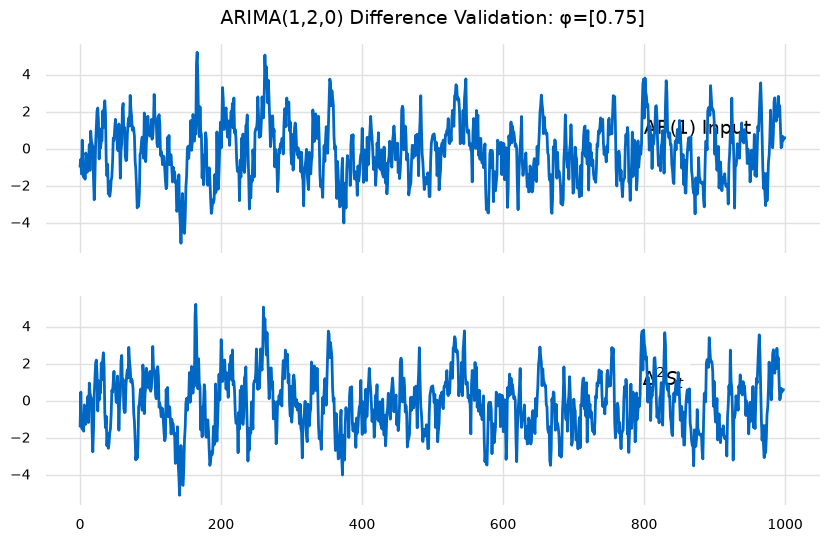

In [16]:
title = f"ARIMA(1,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(1) Input", r"$\Delta^2 S_t$"])

In [17]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   1.93073  │
├────────────────┼────────────┤
│ pvalue         │   0.988186 │
├────────────────┼────────────┤
│ Lags           │   3        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [18]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "4f1ec331-f8a7-42fe-8152-a803729137ca",
                "label": "$t$",
                "value": 1.9307285960011684
            },
            "pval": {
                "test_id": "4f1ec331-f8a7-42fe-8152-a803729137ca",
                "label": "$p-value$",
                "value": 0.9881856009690384
            },
            "params": [],
            "sig": {
                "test_id": "4f1ec331-f8a7-42fe-8152-a803729137ca",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "4f1ec331-f8a7-42fe-8152-a803729137ca",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "4f1ec331-f8a7-42fe-8152-a803729137ca"
        },
       

In [19]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.458309 │
├────────────────┼────────────┤
│ pvalue         │   0.513177 │
├────────────────┼────────────┤
│ Lags           │   1        │
├────────────────┼────────────┤
│ Number Obs     │ 997        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [20]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "4f637d83-8852-4242-9f5a-394b961f8991",
                "label": "$t$",
                "value": -0.4583089840787919
            },
            "pval": {
                "test_id": "4f637d83-8852-4242-9f5a-394b961f8991",
                "label": "$p-value$",
                "value": 0.5131768680575156
            },
            "params": [],
            "sig": {
                "test_id": "4f637d83-8852-4242-9f5a-394b961f8991",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "4f637d83-8852-4242-9f5a-394b961f8991",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "4f637d83-8852-4242-9f5a-394b961f8991"
        },
     

In [21]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.1573      │
├────────────────┼───────────────┤
│ pvalue         │   3.39888e-20 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [22]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "660a067c-bbe8-4afc-a7f7-1b88cbf6e865",
                "label": "$t$",
                "value": -11.15729513250316
            },
            "pval": {
                "test_id": "660a067c-bbe8-4afc-a7f7-1b88cbf6e865",
                "label": "$p-value$",
                "value": 3.398876942006952e-20
            },
            "params": [],
            "sig": {
                "test_id": "660a067c-bbe8-4afc-a7f7-1b88cbf6e865",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "660a067c-bbe8-4afc-a7f7-1b88cbf6e865",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "660a067c-bbe8-4afc-a7f7-1b88cbf6e865"
        },
   

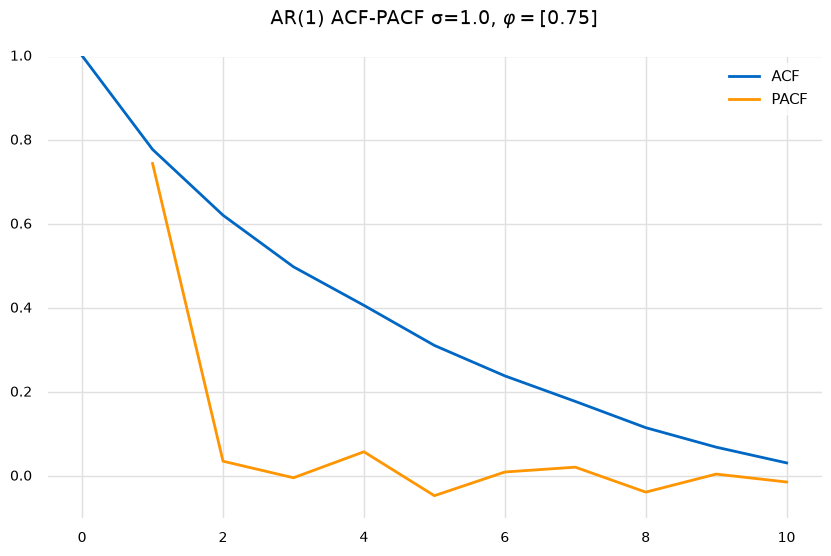

In [23]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [24]:
result, result_model = arima.compute_ar_estimate(diff_2, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1412.871
Date:                Sun, 30 Aug 2026   AIC                           2831.741
Time:                        11:23:24   BIC                           2846.459
Sample:                             0   HQIC                          2837.335
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1107      0.141     -0.785      0.433      -0.387       0.166
ar.L1          0.7768      0.021     37.697      0.000       0.736       0.817
sigma2         0.9926      0.045     21.851      0.000       0.904       1.082
===================================================================================
Ljung-Box (L1) (Q):                   1.01   Jarque-Bera (JB):                 0.57
Prob(Q):                              0.32   Prob(JB):                         0.75
Heteroskedasticity (H):               0.87   Skew:                             0.04
Prob(H) (two-sided):                  0.22   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## $\text{ARIMA}(2,2,0)$ Example

In [25]:
φ = [0.25, 0.4]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

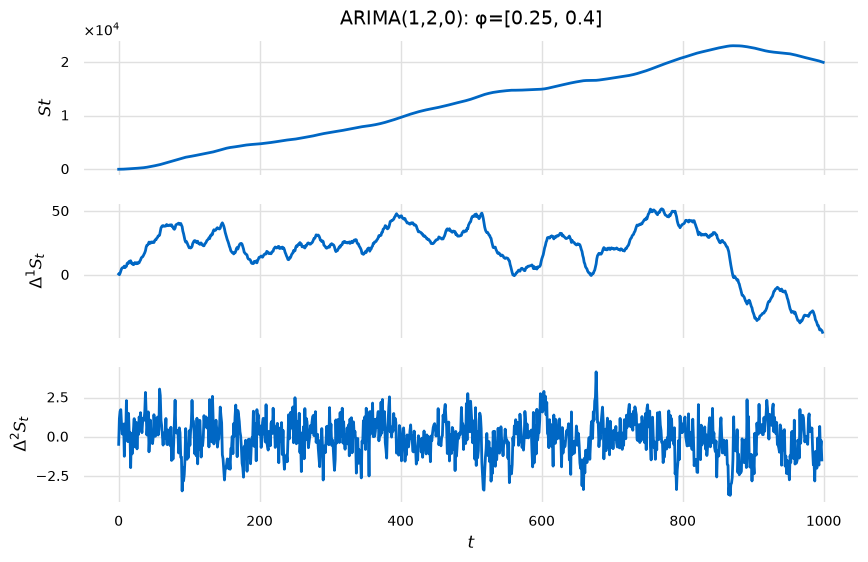

In [26]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

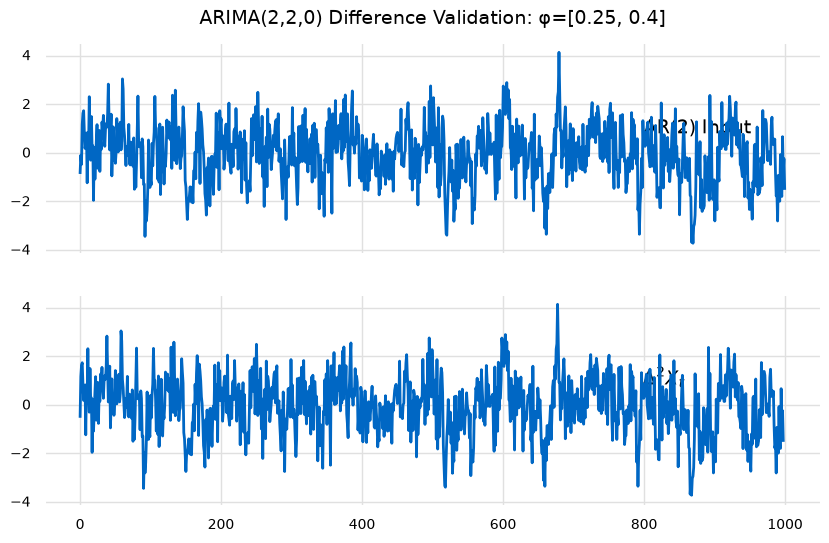

In [27]:
title = f"ARIMA(2,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(2) Input", r"$\Delta^2 X_t$"])

In [28]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -1.01004  │
├────────────────┼────────────┤
│ pvalue         │   0.284091 │
├────────────────┼────────────┤
│ Lags           │   3        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [29]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "ad52b249-2f96-4c70-b76c-7d46154cd93e",
                "label": "$t$",
                "value": -1.0100354038266461
            },
            "pval": {
                "test_id": "ad52b249-2f96-4c70-b76c-7d46154cd93e",
                "label": "$p-value$",
                "value": 0.28409061344384956
            },
            "params": [],
            "sig": {
                "test_id": "ad52b249-2f96-4c70-b76c-7d46154cd93e",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "ad52b249-2f96-4c70-b76c-7d46154cd93e",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "ad52b249-2f96-4c70-b76c-7d46154cd93e"
        },
     

In [30]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -1.09548  │
├────────────────┼────────────┤
│ pvalue         │   0.247433 │
├────────────────┼────────────┤
│ Lags           │   2        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [31]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "8b6652e3-356d-4385-9079-572fd407528d",
                "label": "$t$",
                "value": -1.0954808675610397
            },
            "pval": {
                "test_id": "8b6652e3-356d-4385-9079-572fd407528d",
                "label": "$p-value$",
                "value": 0.24743346015464607
            },
            "params": [],
            "sig": {
                "test_id": "8b6652e3-356d-4385-9079-572fd407528d",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "8b6652e3-356d-4385-9079-572fd407528d",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "8b6652e3-356d-4385-9079-572fd407528d"
        },
     

In [32]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │ -11.3256     │
├────────────────┼──────────────┤
│ pvalue         │   1.5395e-20 │
├────────────────┼──────────────┤
│ Lags           │   1          │
├────────────────┼──────────────┤
│ Number Obs     │ 996          │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [33]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "410ace3d-068c-43bc-8449-e0a2d697a699",
                "label": "$t$",
                "value": -11.32555933402563
            },
            "pval": {
                "test_id": "410ace3d-068c-43bc-8449-e0a2d697a699",
                "label": "$p-value$",
                "value": 1.5394969199188225e-20
            },
            "params": [],
            "sig": {
                "test_id": "410ace3d-068c-43bc-8449-e0a2d697a699",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "410ace3d-068c-43bc-8449-e0a2d697a699",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "410ace3d-068c-43bc-8449-e0a2d697a699"
        },
   

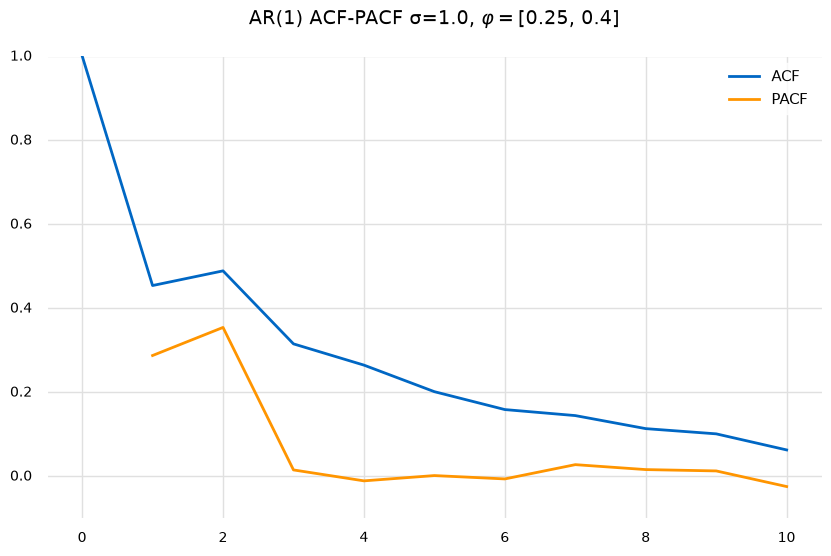

In [34]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [35]:
result, result_model = arima.compute_ar_estimate(diff_2, order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1401.690
Date:                Sun, 30 Aug 2026   AIC                           2811.380
Time:                        11:23:25   BIC                           2831.003
Sample:                             0   HQIC                          2818.839
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0482      0.089     -0.541      0.589      -0.223       0.127
ar.L1          0.2916      0.030      9.643      0.000       0.232       0.351
ar.L2          0.3559      0.031     11.629      0.000       0.296       0.416
sigma2         0.9710      0.045     21.711      0.000       0.883       1.059
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.85
Prob(Q):                              0.88   Prob(JB):                         0.40
Heteroskedasticity (H):               1.02   Skew:                             0.10
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""